# 4_ss_EC_substates.py

In [1]:
#load modules
import pandas as pd
import scanpy as sc
import numpy as np
import anndata as ad
import os
from collections import Counter
from sklearn.decomposition import PCA

#ploting modules
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import seaborn as sns


working_dic="/Users/jiahuiji/Library/CloudStorage/Dropbox/lmu_project/xeno/data/scanpy_object/cell_type/"
output_path="/Users/jiahuiji/Library/CloudStorage/Dropbox/lmu_project/xeno/data/scanpy_object/cell_type/finish_anno/"
os.chdir(working_dic)


#color key define
dimplot_color=mcolors.LinearSegmentedColormap.from_list("custom_cmap", ["#E5E5E5","#4C4DB7"])

In [2]:
#parameter
celltype="EC"

#read in cell type specific adata
adata_raw=sc.read(celltype+"_subset.h5ad")
adata=adata_raw

print(adata)
print(adata.X[:5, :5].toarray())

AnnData object with n_obs × n_vars = 1449 × 36545
    obs: 'n_genes', 'scrublet_score_default', 'predicted_doublets_default', 'scrublet_score_z', 'predicted_doublets_z', 'scrublet_score_log', 'predicted_doublets_log', 'percent_mito', 'percent_ribo', 'percent_ribo_RPS', 'percent_ribo_RPL', 'n_counts', 'solo_softmax_scores', 'solo_logit_scores', 'solo_is_doublet', 'sample', 'batch', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_hs_mt', 'log1p_total_counts_hs_mt', 'pct_counts_hs_mt', 'total_counts_hs_ribo', 'log1p_total_counts_hs_ribo', 'pct_counts_hs_ribo', 'total_counts_ss_mt', 'log1p_total_counts_ss_mt', 'pct_counts_ss_mt', 'total_counts_ss_ribo', 'log1p_total_counts_ss_ribo', 'pct_counts_ss_ribo', 'leiden_02', 'leiden_03', 'leiden_04', 'leiden_05', 'leiden_06', 'leiden_07', 'leiden_08', 'leiden_09', 'leiden_10'

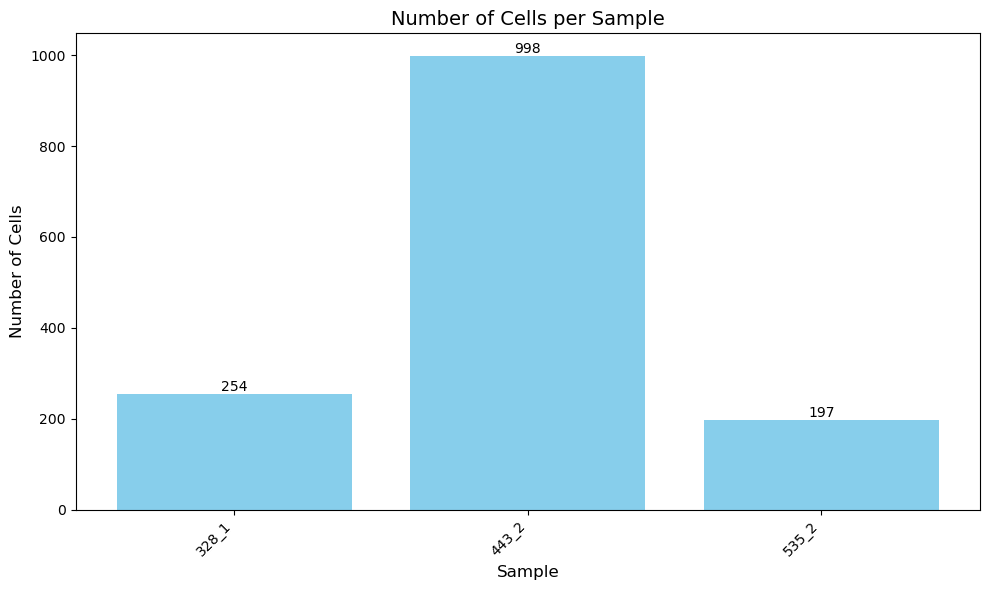

In [3]:
#check the number of nuclei after filters
sample_column = 'sample'
if sample_column not in adata.obs:
    raise ValueError(f"Column '{sample_column}' not found in adata.obs")

cell_counts = adata.obs[sample_column].value_counts()

cell_counts_df = pd.DataFrame({
    'Sample': cell_counts.index,
    'Cell Count': cell_counts.values
}).sort_values(by='Sample')

plt.figure(figsize=(10, 6))
bars = plt.bar(cell_counts_df['Sample'], cell_counts_df['Cell Count'], color='skyblue')
plt.xlabel('Sample', fontsize=12)
plt.ylabel('Number of Cells', fontsize=12)
plt.title('Number of Cells per Sample', fontsize=14)
plt.xticks(rotation=45, ha='right', fontsize=10)

for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width() / 2, height, str(height), 
             ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.show()

# 1. Remove batch effects

/Users/jiahuiji/Library/CloudStorage/Dropbox/app/scanpy/src/scanpy/preprocessing/_highly_variable_genes.py:75: UserWarning: `flavor='seurat_v3'` expects raw count data, but non-integers were found.
  warnings.warn(
/Users/jiahuiji/Library/CloudStorage/Dropbox/app/scanpy/src/scanpy/preprocessing/_simple.py:668: UserWarning: Received a view of an AnnData. Making a copy.
  view_to_actual(adata)
/opt/anaconda3/envs/scanpy/lib/python3.12/site-packages/threadpoolctl.py:1214: RuntimeWarning: 
Found Intel OpenMP ('libiomp') and LLVM OpenMP ('libomp') loaded at
the same time. Both libraries are known to be incompatible and this
can cause random crashes or deadlocks on Linux when loaded in the
same Python program.
Using threadpoolctl may cause crashes or deadlocks. For more
information and possible workarounds, please see
    https://github.com/joblib/threadpoolctl/blob/master/multiple_openmp.md

  warnings.warn(msg, RuntimeWarning)


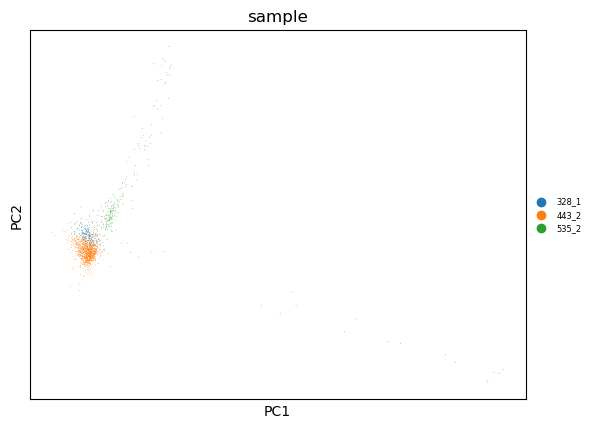

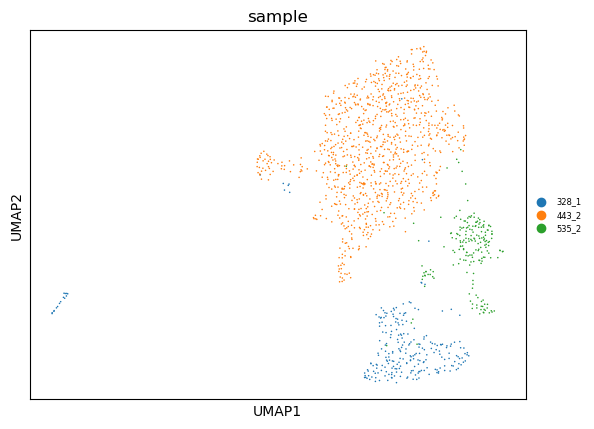

In [4]:
#######before batch effect remover
adata_beforeinte=adata.copy()

sc.pp.normalize_total(adata_beforeinte)
sc.pp.log1p(adata_beforeinte)

#identify highly variable genes 
sc.pp.highly_variable_genes(adata_beforeinte, flavor="seurat_v3")
adata_beforeinte.raw=adata_beforeinte
adata_beforeinte=adata_beforeinte[:, adata_beforeinte.var.highly_variable]
sc.pp.regress_out(adata_beforeinte, ["total_counts", "pct_counts_hs_mt", "pct_counts_ss_mt"])

cells_hvg=adata_beforeinte
cells_hvg.shape
sc.pp.scale(cells_hvg, max_value=10)
sc.pp.pca(cells_hvg, n_comps=50, svd_solver="arpack")
sc.pp.neighbors(cells_hvg, n_neighbors=10, n_pcs=40)
sc.tl.umap(cells_hvg)
sc.pl.pca_scatter(cells_hvg, color=["sample"], size = 1, legend_fontsize = 6)

sc.pl.umap(cells_hvg, color=["sample"], size = 5, legend_fontsize = 6)

/Users/jiahuiji/Library/CloudStorage/Dropbox/app/scanpy/src/scanpy/preprocessing/_highly_variable_genes.py:75: UserWarning: `flavor='seurat_v3'` expects raw count data, but non-integers were found.
  warnings.warn(
/Users/jiahuiji/Library/CloudStorage/Dropbox/app/scanpy/src/scanpy/preprocessing/_scale.py:318: UserWarning: Received a view of an AnnData. Making a copy.
  view_to_actual(adata)


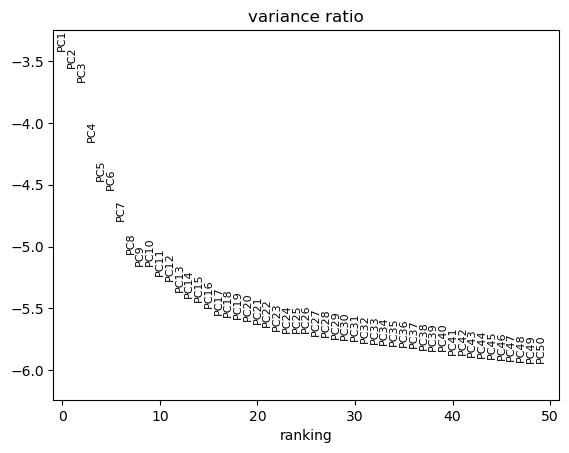

In [6]:
#######after batch effect remover
adata_afterinte=adata.copy()

sc.pp.normalize_total(adata_afterinte)
sc.pp.log1p(adata_afterinte)

#identify highly variable genes 
sc.pp.highly_variable_genes(adata_afterinte, flavor="seurat_v3")
adata_afterinte.raw=adata_afterinte
adata_afterinte=adata_afterinte[:, adata_afterinte.var['highly_variable']]

sc.pp.regress_out(adata_beforeinte, ["total_counts", "pct_counts_hs_mt", "pct_counts_ss_mt"])
sc.pp.scale(adata_afterinte, max_value=10)

sc.pp.pca(adata_afterinte, n_comps=50, svd_solver="arpack")
sc.pl.pca_variance_ratio(adata_afterinte, log=True, n_pcs=50)

2025-10-04 15:50:24,579 - harmonypy - INFO - Computing initial centroids with sklearn.KMeans...
2025-10-04 15:50:24,856 - harmonypy - INFO - sklearn.KMeans initialization complete.
2025-10-04 15:50:24,861 - harmonypy - INFO - Iteration 1 of 10
2025-10-04 15:50:25,115 - harmonypy - INFO - Iteration 2 of 10
2025-10-04 15:50:25,232 - harmonypy - INFO - Iteration 3 of 10
2025-10-04 15:50:25,357 - harmonypy - INFO - Iteration 4 of 10
2025-10-04 15:50:25,477 - harmonypy - INFO - Iteration 5 of 10
2025-10-04 15:50:25,596 - harmonypy - INFO - Iteration 6 of 10
2025-10-04 15:50:25,720 - harmonypy - INFO - Iteration 7 of 10
2025-10-04 15:50:25,864 - harmonypy - INFO - Iteration 8 of 10
2025-10-04 15:50:25,992 - harmonypy - INFO - Iteration 9 of 10
2025-10-04 15:50:26,110 - harmonypy - INFO - Iteration 10 of 10
2025-10-04 15:50:26,229 - harmonypy - INFO - Stopped before convergence


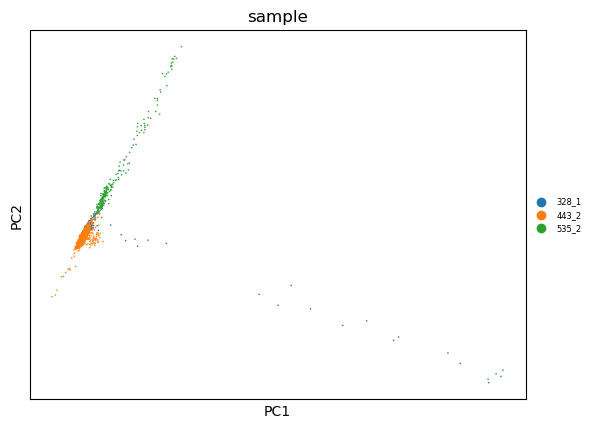

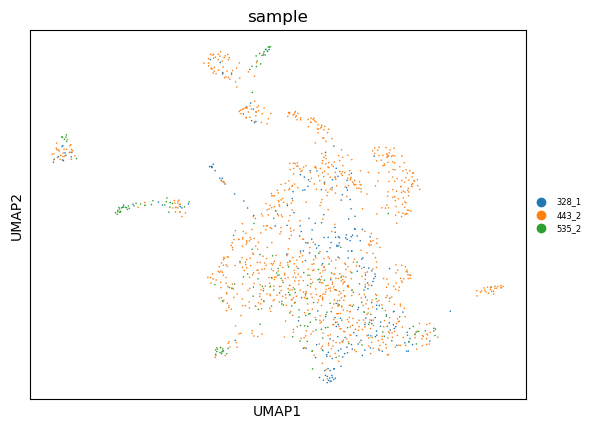

In [7]:
#run harmony
sc.external.pp.harmony_integrate(adata_afterinte, "sample", random_state=12, epsilon_cluster=-np.inf, epsilon_harmony=-np.inf)

sc.pp.neighbors(adata_afterinte, n_neighbors=15, n_pcs=13, use_rep="X_pca_harmony")
sc.tl.umap(adata_afterinte)
sc.pl.pca_scatter(adata_afterinte, color=["sample"], size=5, legend_fontsize=6)
sc.pl.umap(adata_afterinte, color=["sample"], size=5, legend_fontsize=6)

/var/folders/_c/m4bk3hk95tv6mk2gt77lk_gc0000gn/T/ipykernel_54532/521441958.py:1: FutureWarning: In the future, the default backend for leiden will be igraph instead of leidenalg.

 To achieve the future defaults please pass: flavor="igraph" and n_iterations=2.  directed must also be False to work with igraph's implementation.
  sc.tl.leiden(adata_afterinte, resolution = 0.2 ,key_added="leiden_02")


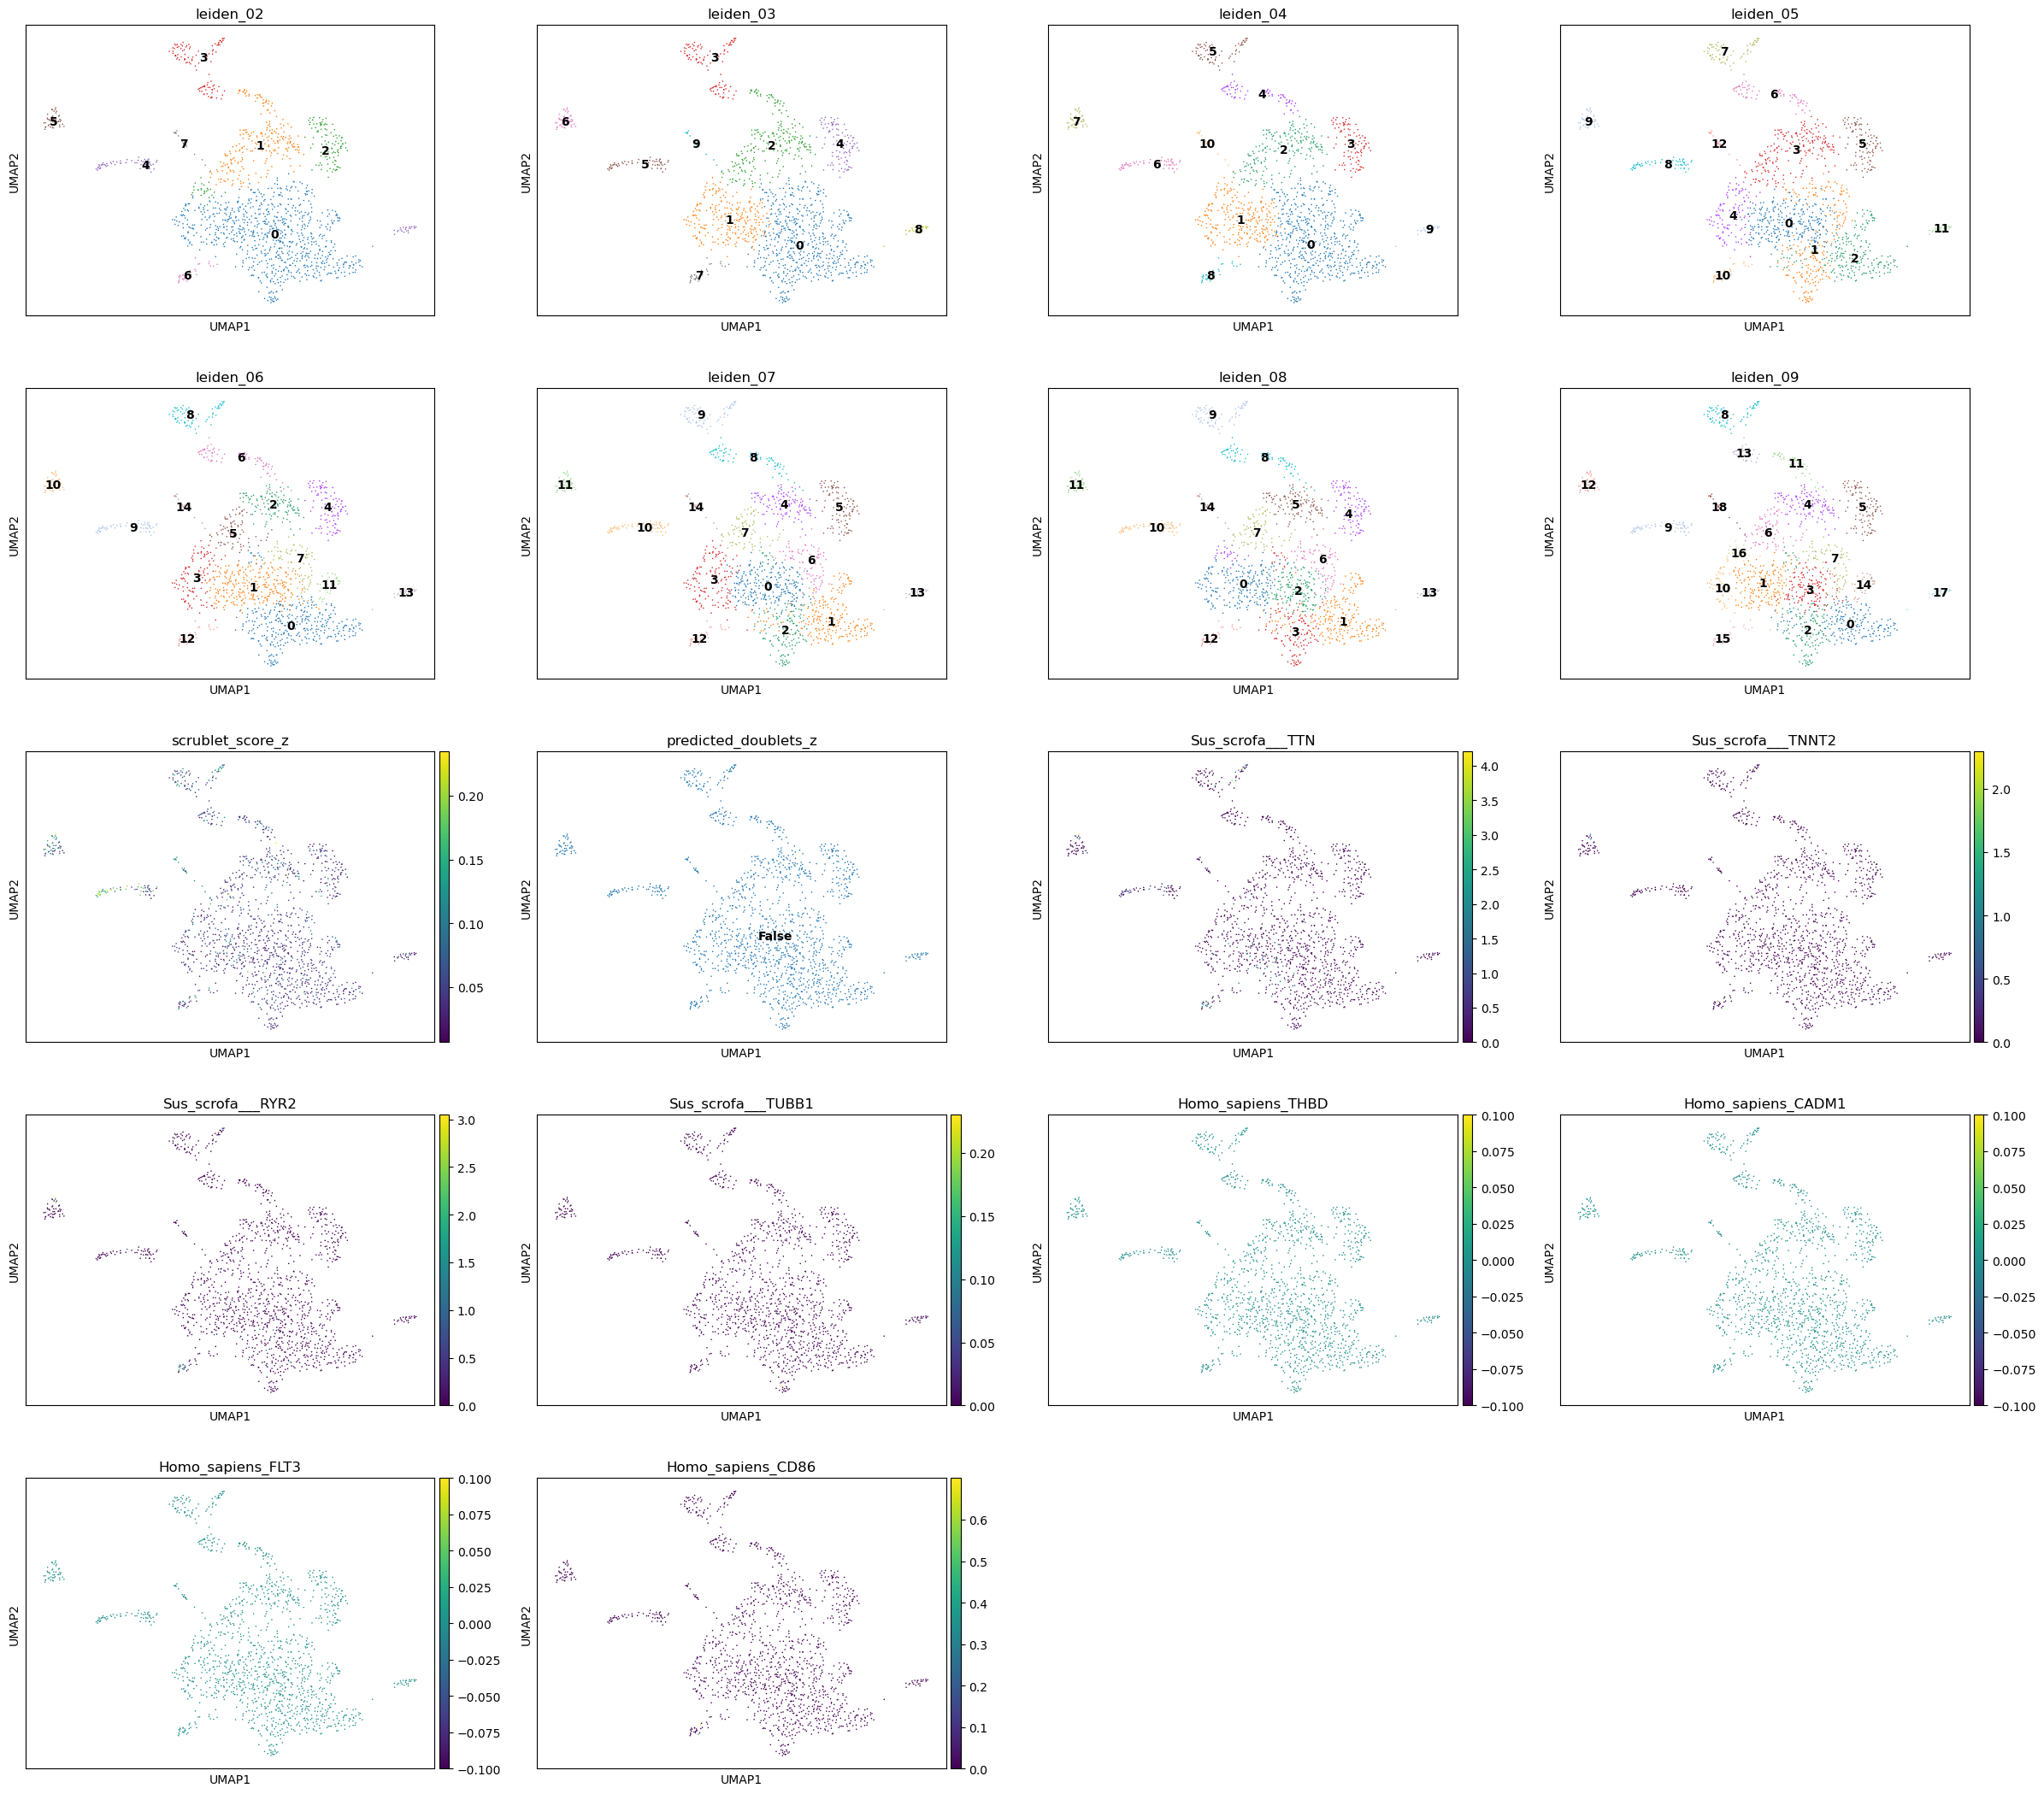

In [8]:
sc.tl.leiden(adata_afterinte, resolution = 0.2 ,key_added="leiden_02")
sc.tl.leiden(adata_afterinte, resolution = 0.3 ,key_added="leiden_03")
sc.tl.leiden(adata_afterinte, resolution = 0.4 ,key_added="leiden_04")
sc.tl.leiden(adata_afterinte, resolution = 0.5 ,key_added="leiden_05")
sc.tl.leiden(adata_afterinte, resolution = 0.6 ,key_added="leiden_06")
sc.tl.leiden(adata_afterinte, resolution = 0.7 ,key_added="leiden_07")
sc.tl.leiden(adata_afterinte, resolution = 0.8 ,key_added="leiden_08")
sc.tl.leiden(adata_afterinte, resolution = 0.9 ,key_added="leiden_09")


sc.pl.umap(
    adata_afterinte,
    color=["leiden_02", "leiden_03", "leiden_04", "leiden_05", "leiden_06", "leiden_07", "leiden_08", "leiden_09", "scrublet_score_z",
           "predicted_doublets_z", "Sus_scrofa___TTN", "Sus_scrofa___TNNT2", "Sus_scrofa___RYR2", "Sus_scrofa___TUBB1", "Homo_sapiens_THBD", "Homo_sapiens_CADM1", "Homo_sapiens_FLT3", "Homo_sapiens_CD86"],
    legend_loc="on data",
    size=5
)

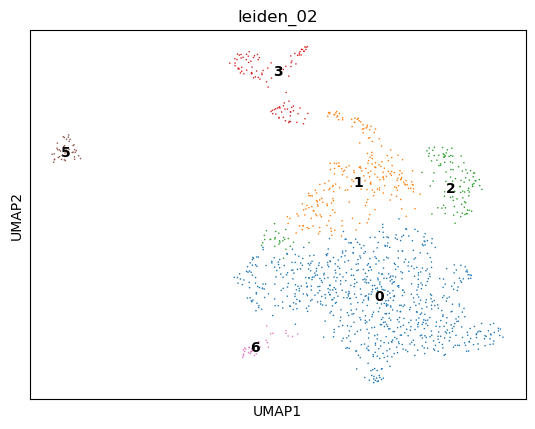

[[0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0.]]


AnnData object with n_obs × n_vars = 1347 × 36545
    obs: 'n_genes', 'scrublet_score_default', 'predicted_doublets_default', 'scrublet_score_z', 'predicted_doublets_z', 'scrublet_score_log', 'predicted_doublets_log', 'percent_mito', 'percent_ribo', 'percent_ribo_RPS', 'percent_ribo_RPL', 'n_counts', 'solo_softmax_scores', 'solo_logit_scores', 'solo_is_doublet', 'sample', 'batch', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_hs_mt', 'log1p_total_counts_hs_mt', 'pct_counts_hs_mt', 'total_counts_hs_ribo', 'log1p_total_counts_hs_ribo', 'pct_counts_hs_ribo', 'total_counts_ss_mt', 'log1p_total_counts_ss_mt', 'pct_counts_ss_mt', 'total_counts_ss_ribo', 'log1p_total_counts_ss_ribo', 'pct_counts_ss_ribo', 'leiden_02', 'leiden_03', 'leiden_04', 'leiden_05', 'leiden_06', 'leiden_07', 'leiden_08', 'leiden_09', 'leiden_10'

In [9]:
#remove cluster 5 and cluster 8 for leiden_02
remove_cluster=['4', '7']

adata_nobackground=adata_raw[~adata_afterinte.obs.leiden_02.isin(remove_cluster)].copy()

adata_nobackground
sc.pl.umap(
    adata_afterinte[~adata_afterinte.obs.leiden_02.isin(remove_cluster)].copy(),
    color=["leiden_02"],
    legend_loc="on data",
    size=5)
print(adata_nobackground.X[:5, :5].toarray())
adata_nobackground

/Users/jiahuiji/Library/CloudStorage/Dropbox/app/scanpy/src/scanpy/preprocessing/_highly_variable_genes.py:75: UserWarning: `flavor='seurat_v3'` expects raw count data, but non-integers were found.
  warnings.warn(
/Users/jiahuiji/Library/CloudStorage/Dropbox/app/scanpy/src/scanpy/preprocessing/_scale.py:318: UserWarning: Received a view of an AnnData. Making a copy.
  view_to_actual(adata)


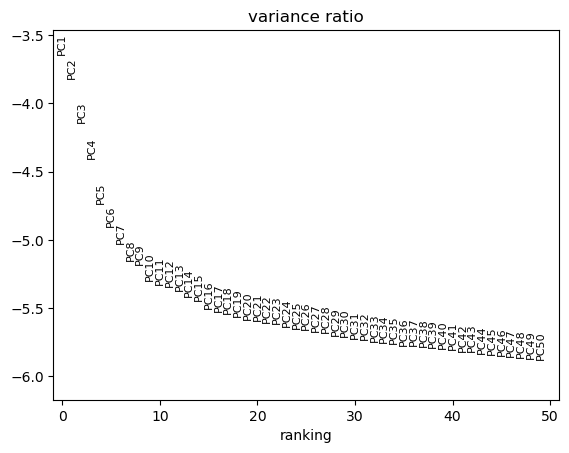

In [10]:
#######after batch effect remover
adata_afterinte=adata_nobackground.copy()

sc.pp.normalize_total(adata_afterinte)
sc.pp.log1p(adata_afterinte)

#identify highly variable genes 
sc.pp.highly_variable_genes(adata_afterinte, flavor="seurat_v3")
adata_afterinte.raw=adata_afterinte
adata_afterinte=adata_afterinte[:, adata_afterinte.var['highly_variable']]

sc.pp.regress_out(adata_beforeinte, ["total_counts", "pct_counts_hs_mt", "pct_counts_ss_mt"])
sc.pp.scale(adata_afterinte, max_value=10)

sc.pp.pca(adata_afterinte, n_comps=50, svd_solver="arpack")
sc.pl.pca_variance_ratio(adata_afterinte, log=True, n_pcs=50)

2025-10-04 15:51:20,980 - harmonypy - INFO - Computing initial centroids with sklearn.KMeans...
2025-10-04 15:51:21,189 - harmonypy - INFO - sklearn.KMeans initialization complete.
2025-10-04 15:51:21,193 - harmonypy - INFO - Iteration 1 of 10
2025-10-04 15:51:21,338 - harmonypy - INFO - Iteration 2 of 10
2025-10-04 15:51:21,458 - harmonypy - INFO - Iteration 3 of 10
2025-10-04 15:51:21,564 - harmonypy - INFO - Iteration 4 of 10
2025-10-04 15:51:21,672 - harmonypy - INFO - Iteration 5 of 10
2025-10-04 15:51:21,785 - harmonypy - INFO - Iteration 6 of 10
2025-10-04 15:51:21,898 - harmonypy - INFO - Iteration 7 of 10
2025-10-04 15:51:22,075 - harmonypy - INFO - Iteration 8 of 10
2025-10-04 15:51:22,332 - harmonypy - INFO - Iteration 9 of 10
2025-10-04 15:51:22,469 - harmonypy - INFO - Iteration 10 of 10
2025-10-04 15:51:22,583 - harmonypy - INFO - Stopped before convergence


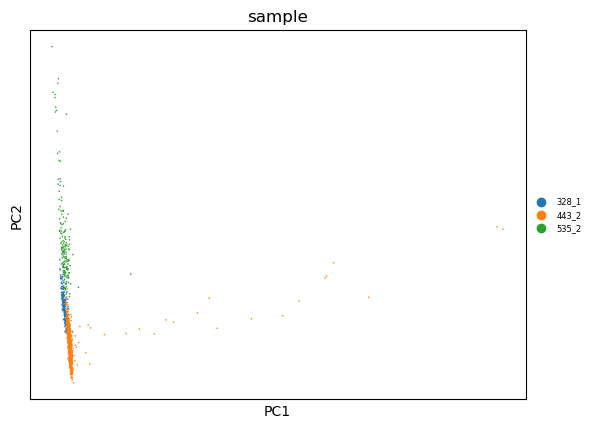

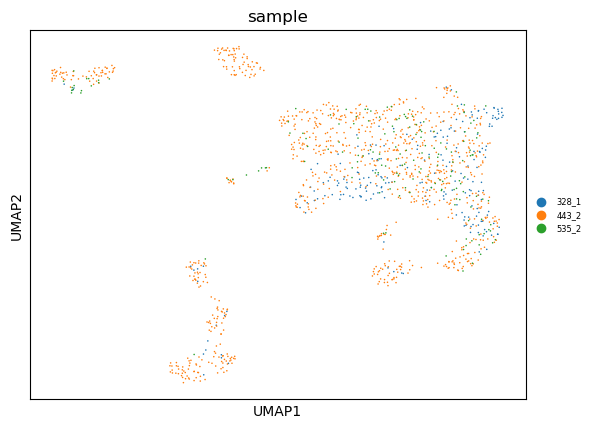

In [11]:
#run harmony
sc.external.pp.harmony_integrate(adata_afterinte, "sample", random_state=12, epsilon_cluster=-np.inf, epsilon_harmony=-np.inf)

sc.pp.neighbors(adata_afterinte, n_neighbors=15, n_pcs=13, use_rep="X_pca_harmony")
sc.tl.umap(adata_afterinte)
sc.pl.pca_scatter(adata_afterinte, color=["sample"], size=5, legend_fontsize=6)
sc.pl.umap(adata_afterinte, color=["sample"], size=5, legend_fontsize=6)

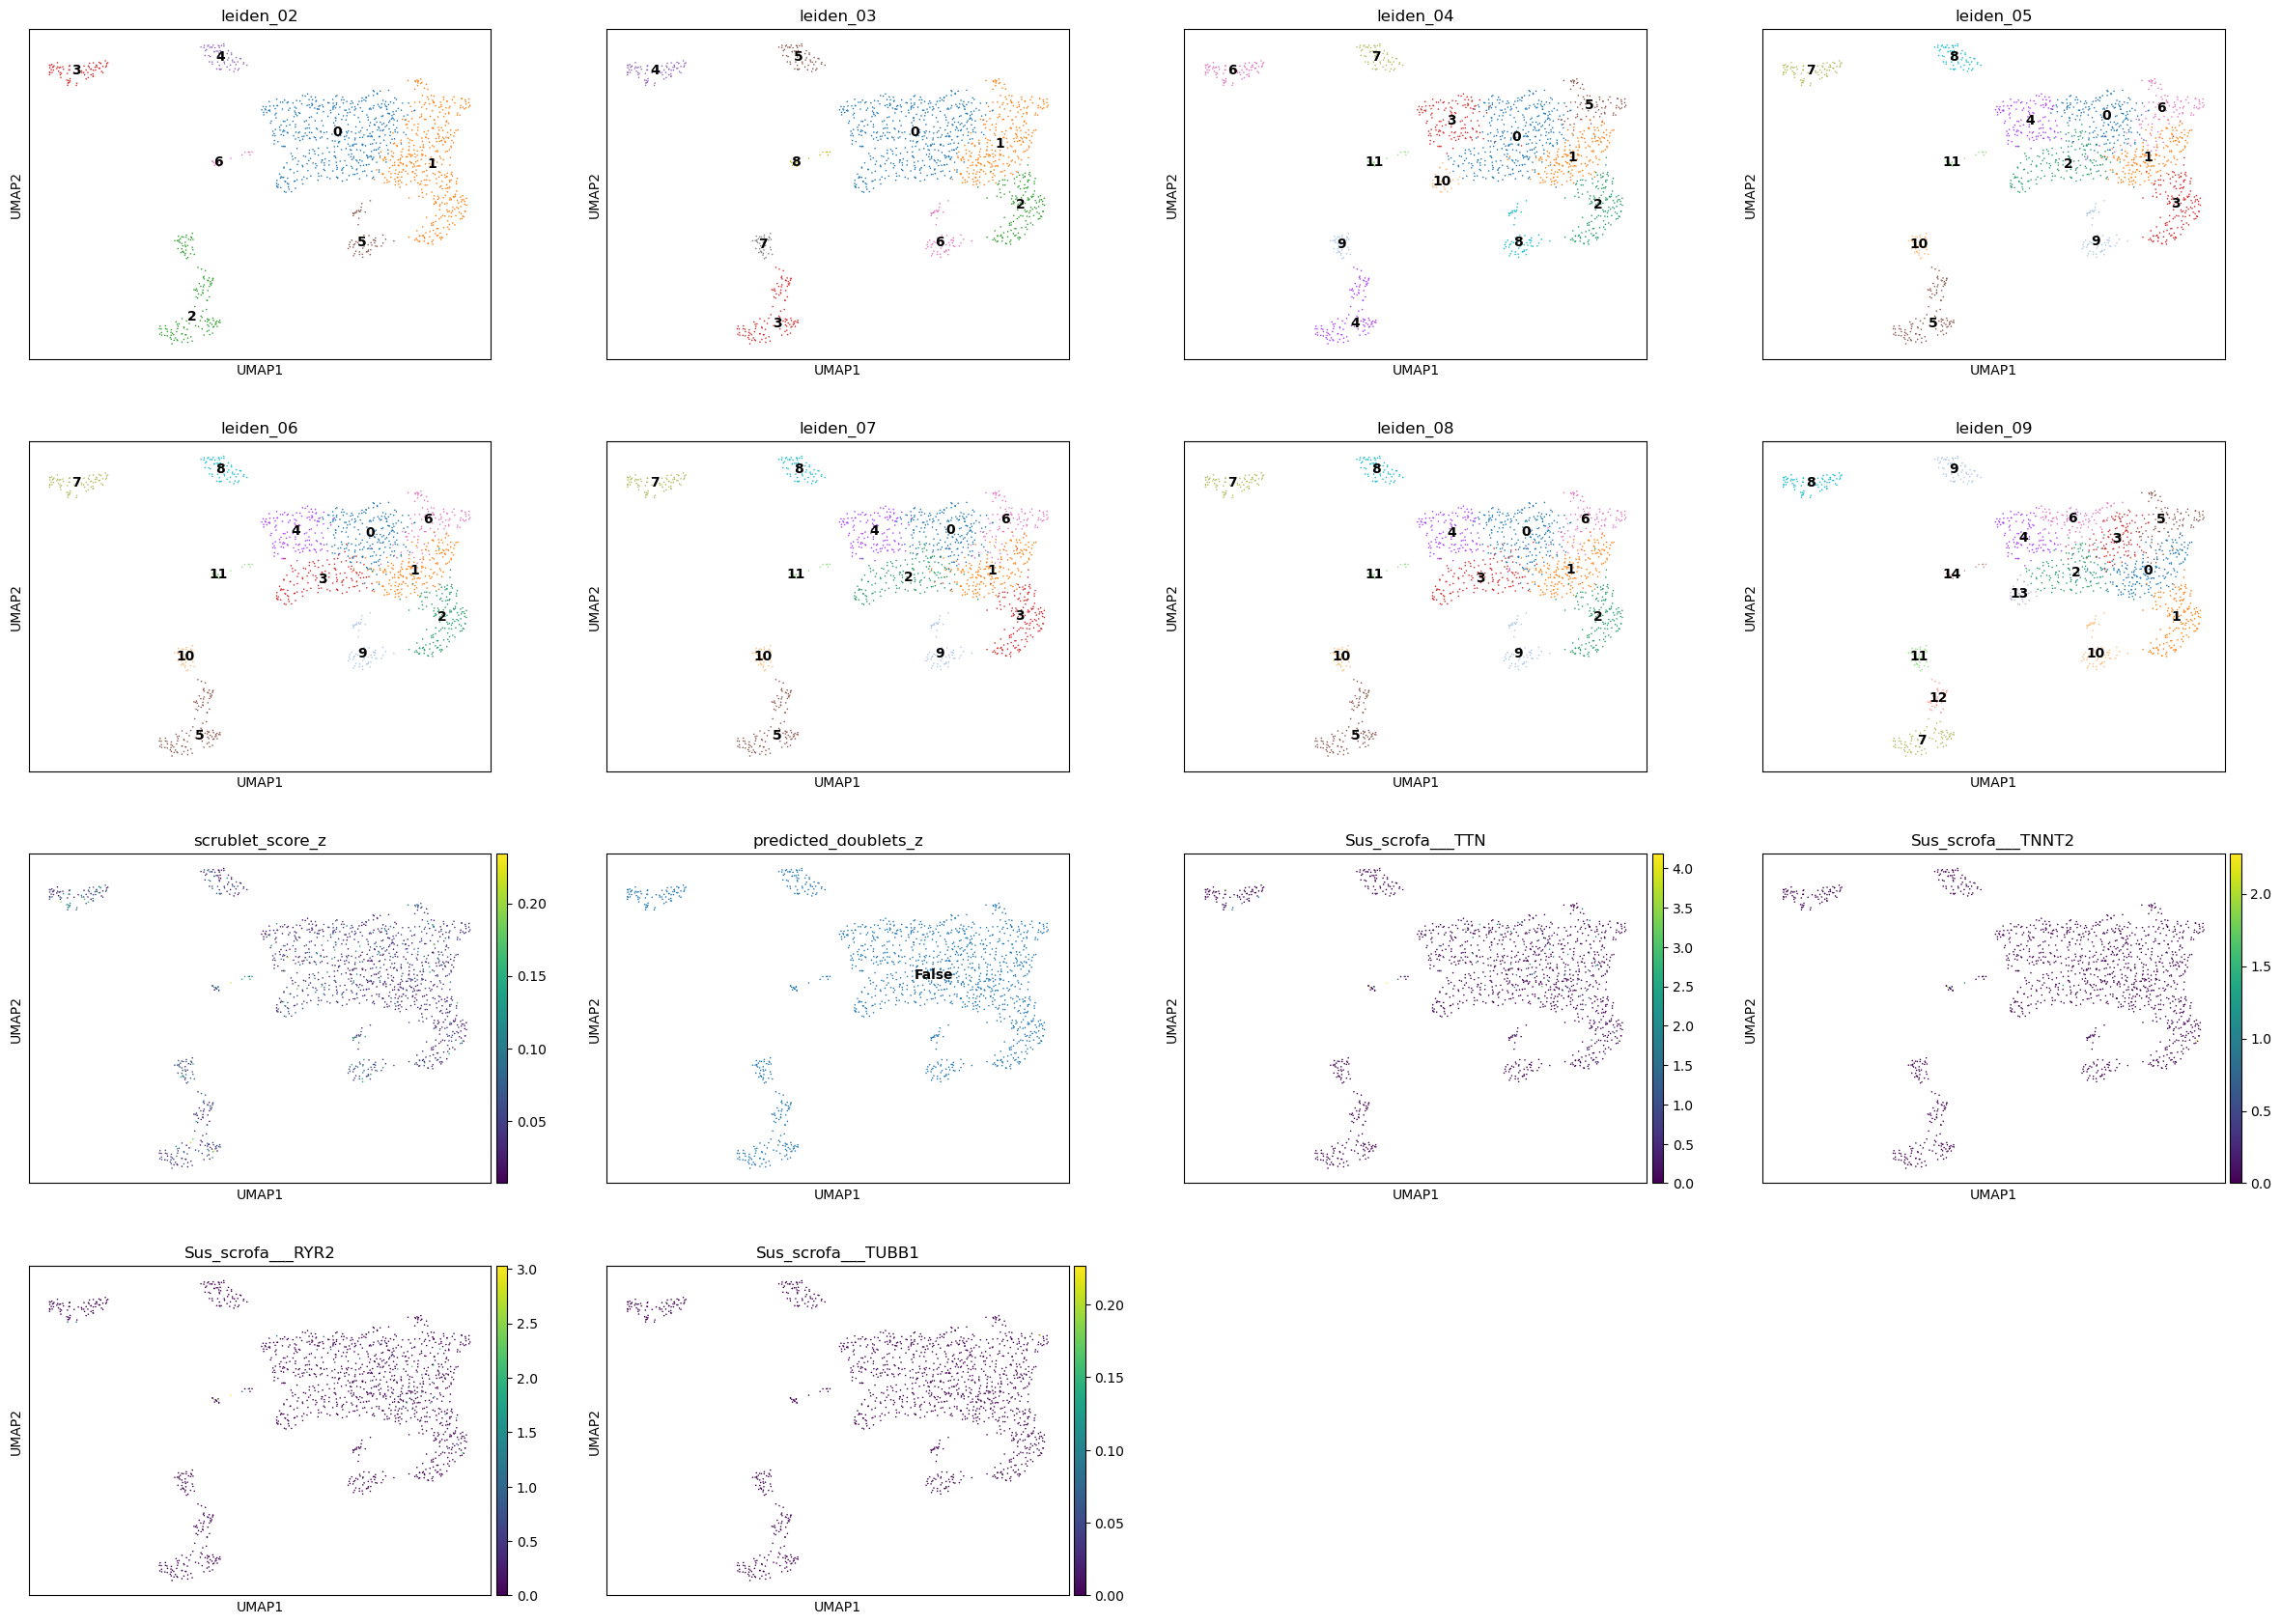

In [14]:
sc.tl.leiden(adata_afterinte, resolution = 0.2 ,key_added="leiden_02")
sc.tl.leiden(adata_afterinte, resolution = 0.3 ,key_added="leiden_03")
sc.tl.leiden(adata_afterinte, resolution = 0.4 ,key_added="leiden_04")
sc.tl.leiden(adata_afterinte, resolution = 0.5 ,key_added="leiden_05")
sc.tl.leiden(adata_afterinte, resolution = 0.6 ,key_added="leiden_06")
sc.tl.leiden(adata_afterinte, resolution = 0.7 ,key_added="leiden_07")
sc.tl.leiden(adata_afterinte, resolution = 0.8 ,key_added="leiden_08")
sc.tl.leiden(adata_afterinte, resolution = 0.9 ,key_added="leiden_09")


sc.pl.umap(
    adata_afterinte,
    color=["leiden_02", "leiden_03", "leiden_04", "leiden_05", "leiden_06", "leiden_07", "leiden_08", "leiden_09", "scrublet_score_z",
           "predicted_doublets_z", "Sus_scrofa___TTN", "Sus_scrofa___TNNT2", "Sus_scrofa___RYR2", "Sus_scrofa___TUBB1"],
    legend_loc="on data",
    size=5
)

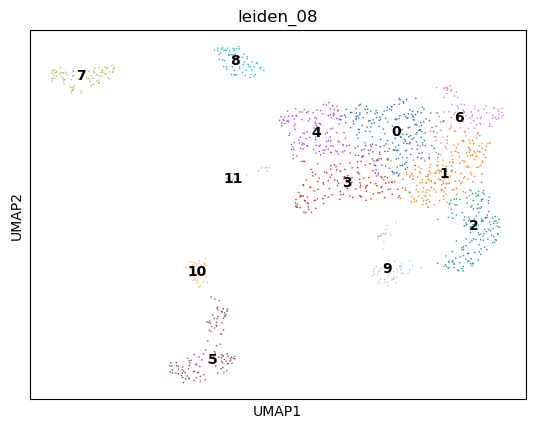

In [15]:
sc.pl.umap(
    adata_afterinte,
    color=["leiden_08"],
    legend_loc="on data",
    size=5
)

In [16]:
#see the similarity of clusters
aggr = {}
for state in adata_afterinte.obs['leiden_08'].cat.categories:
    subset = adata_afterinte.raw[adata_afterinte.obs['leiden_08'].isin([state])]
    aggr[state] = np.squeeze(np.asarray(subset.X.mean(axis=0)))
    del subset

aggr=pd.DataFrame.from_dict(aggr)

aggr.corr(method='pearson').style.background_gradient(cmap='RdPu')

,0,1,2,3,4,5,6,7,8,9,10,11
0,1.000000,0.961697,0.960482,0.941978,0.961986,0.951480,0.945803,0.938261,0.932364,0.932318,0.924485,0.917390
1,0.961697,1.000000,0.979494,0.954362,0.945880,0.926541,0.968172,0.939700,0.946434,0.944554,0.953116,0.910815
2,0.960482,0.979494,1.000000,0.940997,0.925639,0.915495,0.961417,0.925456,0.915086,0.933291,0.934500,0.898346
3,0.941978,0.954362,0.940997,1.000000,0.950349,0.958846,0.958271,0.949997,0.939626,0.933443,0.929816,0.900253
4,0.961986,0.945880,0.925639,0.950349,1.000000,0.969848,0.917726,0.949480,0.971349,0.934983,0.917987,0.917561
5,0.951480,0.926541,0.915495,0.958846,0.969848,1.000000,0.917414,0.957996,0.949701,0.929393,0.912080,0.903483
6,0.945803,0.968172,0.961417,0.958271,0.917726,0.917414,1.000000,0.925860,0.907809,0.927029,0.950204,0.888576
7,0.938261,0.939700,0.925456,0.949997,0.949480,0.957996,0.925860,1.000000,0.949794,0.933393,0.934978,0.909181
8,0.932364,0.946434,0.915086,0.939626,0.971349,0.949701,0.907809,0.949794,1.000000,0.927507,0.919871,0.897489
9,0.932318,0.944554,0.933291,0.933443,0.934983,0.929393,0.927029,0.933393,0.927507,1.000000,0.936205,0.900755


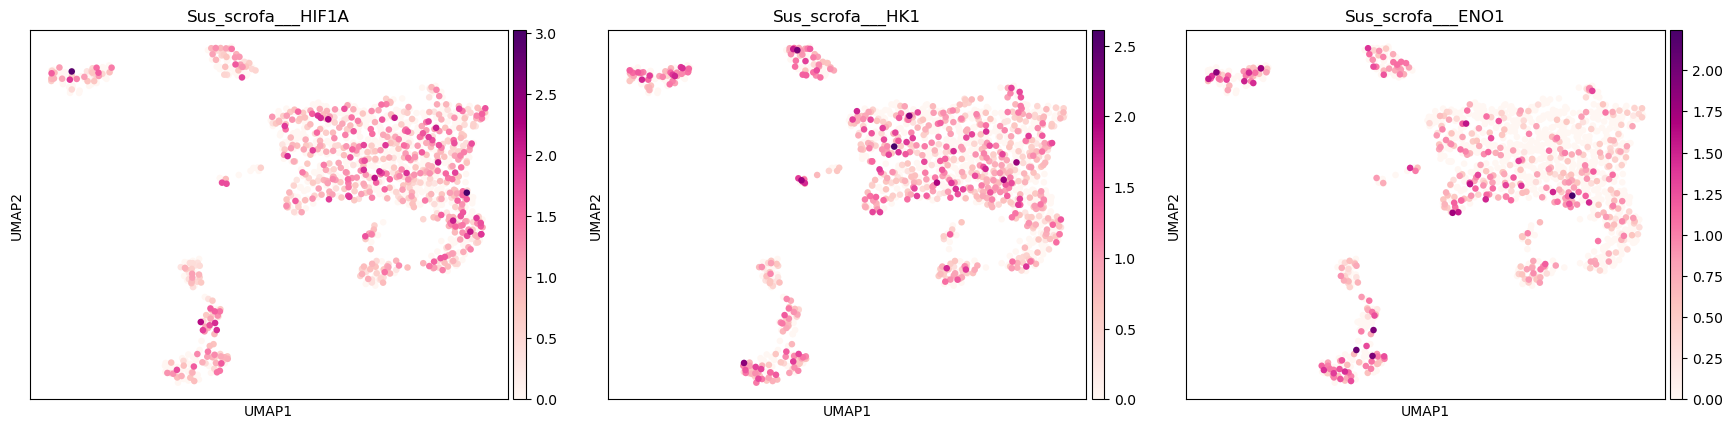

In [17]:
marker=["Sus_scrofa___HIF1A", "Sus_scrofa___HK1", "Sus_scrofa___ENO1"]
sc.pl.umap(adata_afterinte, color=marker, cmap='RdPu', wspace=0.1, ncols=5)

categories: 0, 1, 2, etc.
var_group_labels: Pan, Capillary, Arterial, etc.


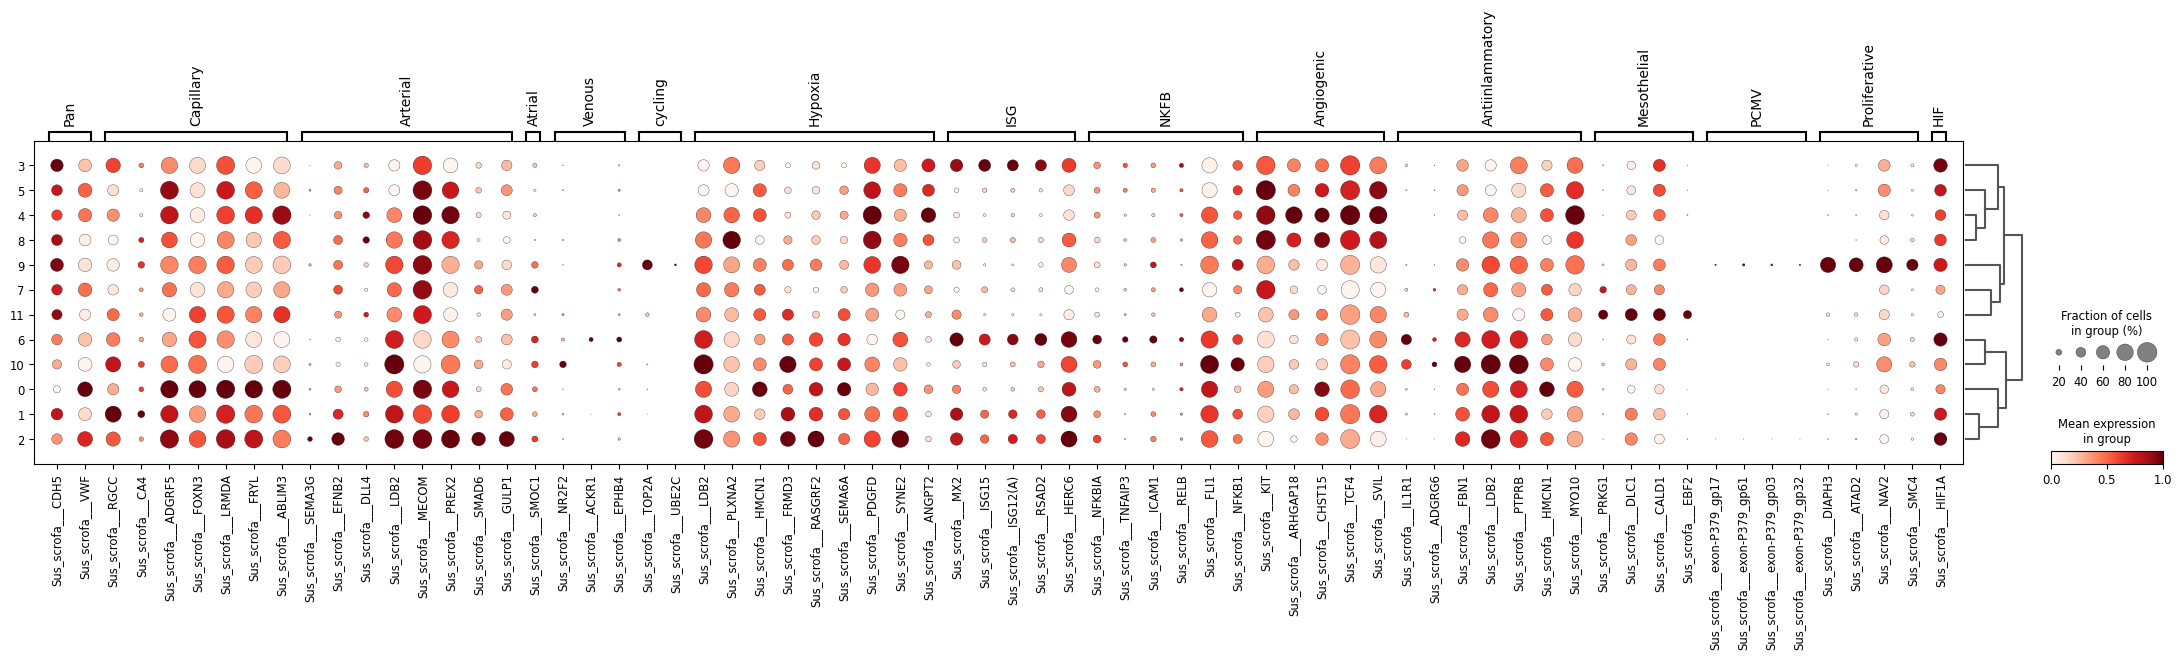

categories: 4, 7, 8
var_group_labels: Pan, Capillary, Arterial, etc.


/Users/jiahuiji/Library/CloudStorage/Dropbox/app/scanpy/src/scanpy/tools/_dendrogram.py:193: ImplicitModificationWarning: Trying to modify attribute `._uns` of view, initializing view as actual.
  adata.uns[key_added] = dat


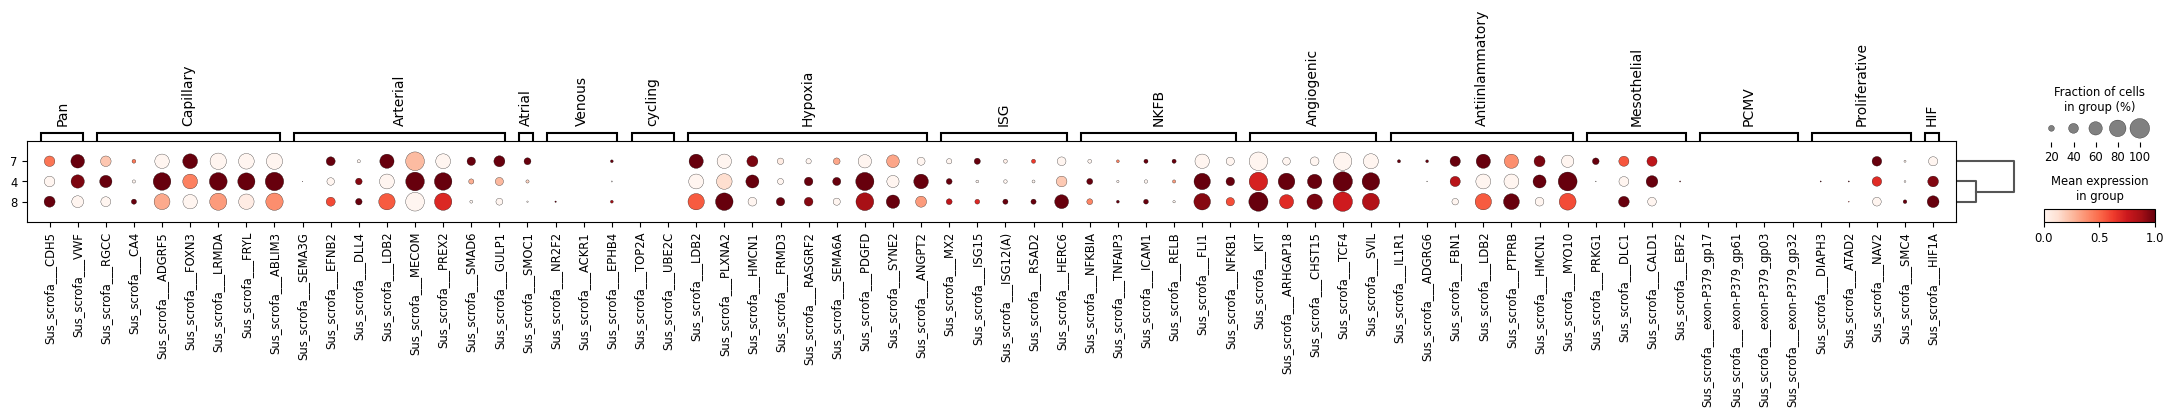

In [18]:
#Markers for MO and DC
marker_genes={
             'Pan':['Sus_scrofa___CDH5', 'Sus_scrofa___VWF'],
             'Capillary':['Sus_scrofa___RGCC', 'Sus_scrofa___CA4', 'Sus_scrofa___ADGRF5', 'Sus_scrofa___FOXN3', 'Sus_scrofa___LRMDA', 'Sus_scrofa___FRYL', 'Sus_scrofa___ABLIM3'],
             'Arterial':['Sus_scrofa___SEMA3G', 'Sus_scrofa___EFNB2', 'Sus_scrofa___DLL4', 'Sus_scrofa___LDB2',
             'Sus_scrofa___MECOM', 'Sus_scrofa___PREX2', 'Sus_scrofa___SMAD6', 'Sus_scrofa___GULP1'],
             'Atrial':['Sus_scrofa___SMOC1'],
             'Venous': ['Sus_scrofa___NR2F2', 'Sus_scrofa___ACKR1', 'Sus_scrofa___EPHB4'],
             'cycling': ['Sus_scrofa___TOP2A', 'Sus_scrofa___UBE2C'],
             'Hypoxia': ['Sus_scrofa___LDB2', 'Sus_scrofa___PLXNA2', 'Sus_scrofa___HMCN1', 'Sus_scrofa___FRMD3',
             'Sus_scrofa___RASGRF2', 'Sus_scrofa___SEMA6A', 'Sus_scrofa___PDGFD', 'Sus_scrofa___SYNE2', 'Sus_scrofa___ANGPT2'],
             'ISG': ['Sus_scrofa___MX2', 'Sus_scrofa___ISG15', 'Sus_scrofa___ISG12(A)', 'Sus_scrofa___RSAD2', 'Sus_scrofa___HERC6'], 
             'NKFB': ['Sus_scrofa___NFKBIA', 'Sus_scrofa___TNFAIP3', 'Sus_scrofa___ICAM1', 'Sus_scrofa___RELB', 'Sus_scrofa___FLI1', 'Sus_scrofa___NFKB1'], 
             'Angiogenic':['Sus_scrofa___KIT', 'Sus_scrofa___ARHGAP18', 'Sus_scrofa___CHST15', 'Sus_scrofa___TCF4',
             'Sus_scrofa___SVIL'],
             'Antiinlammatory': ['Sus_scrofa___IL1R1', 'Sus_scrofa___ADGRG6', 'Sus_scrofa___FBN1', 'Sus_scrofa___LDB2', 'Sus_scrofa___PTPRB', 'Sus_scrofa___HMCN1', 'Sus_scrofa___MYO10'],
             'Mesothelial': ['Sus_scrofa___PRKG1', 'Sus_scrofa___DLC1', 'Sus_scrofa___CALD1', 'Sus_scrofa___EBF2'],
             'PCMV': ['Sus_scrofa___exon-P379_gp17', 'Sus_scrofa___exon-P379_gp61', 'Sus_scrofa___exon-P379_gp03', 'Sus_scrofa___exon-P379_gp32'],
             'Proliferative': ['Sus_scrofa___DIAPH3', 'Sus_scrofa___ATAD2', 'Sus_scrofa___NAV2', 'Sus_scrofa___SMC4'],
             'HIF': ["Sus_scrofa___HIF1A"]
                          }

sc.pl.dotplot(adata_afterinte, marker_genes, "leiden_08", dendrogram=True, log=True, standard_scale="var")

#Recompute dendrogram on filtered data
cells_to_keep = adata_afterinte.obs['leiden_08'].isin(['7', '8', '4'])
adata_filtered = adata_afterinte[cells_to_keep, :] 
sc.tl.dendrogram(adata_filtered, groupby='leiden_08')
sc.pl.dotplot(adata_filtered, marker_genes, "leiden_08", dendrogram=True, log=True, standard_scale="var")

In [20]:
#Markers for MO and DC
marker_genes={
             'PCMV': ['Sus_scrofa___exon-P379_gp17', 'Sus_scrofa___exon-P379_gp61', 'Sus_scrofa___exon-P379_gp03', 'Sus_scrofa___exon-P379_gp32'],
             'cycling': ['Sus_scrofa___TOP2A', 'Sus_scrofa___UBE2C'],
             'Proliferative': ['Sus_scrofa___DIAPH3', 'Sus_scrofa___ATAD2', 'Sus_scrofa___NAV2', 'Sus_scrofa___SMC4'],
                          }

sc.pl.dotplot(adata_afterinte, marker_genes, "cell_state", dendrogram=True, log=True, standard_scale="var")

ValueError: groupby has to be a valid observation. Given cell_state, is not in observations: ['n_genes', 'scrublet_score_default', 'predicted_doublets_default', 'scrublet_score_z', 'predicted_doublets_z', 'scrublet_score_log', 'predicted_doublets_log', 'percent_mito', 'percent_ribo', 'percent_ribo_RPS', 'percent_ribo_RPL', 'n_counts', 'solo_softmax_scores', 'solo_logit_scores', 'solo_is_doublet', 'sample', 'batch', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_hs_mt', 'log1p_total_counts_hs_mt', 'pct_counts_hs_mt', 'total_counts_hs_ribo', 'log1p_total_counts_hs_ribo', 'pct_counts_hs_ribo', 'total_counts_ss_mt', 'log1p_total_counts_ss_mt', 'pct_counts_ss_mt', 'total_counts_ss_ribo', 'log1p_total_counts_ss_ribo', 'pct_counts_ss_ribo', 'leiden_02', 'leiden_03', 'leiden_04', 'leiden_05', 'leiden_06', 'leiden_07', 'l

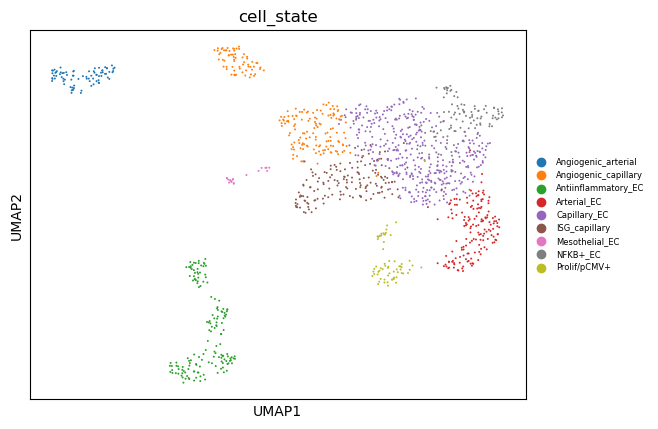

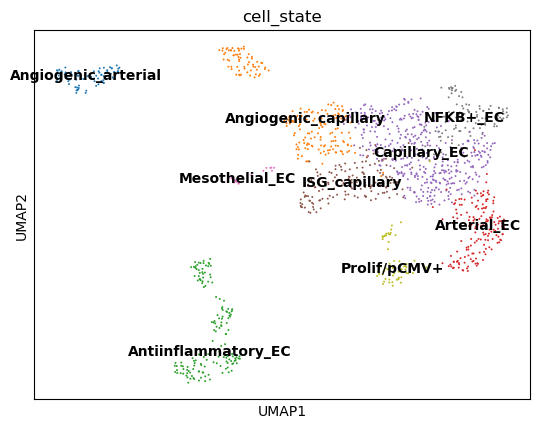

In [21]:
cluster_to_celltype = {
    '0': 'Capillary_EC',
    '1': 'Capillary_EC',
    '2': 'Arterial_EC',
    '3': 'ISG_capillary',
    '4': 'Angiogenic_capillary',
    '5': 'Antiinflammatory_EC', 
    '6': 'NFKB+_EC',
    '7': 'Angiogenic_arterial',
    '8': 'Angiogenic_capillary',
    '9': 'Prolif/pCMV+',
    '10': 'Antiinflammatory_EC',
    '11': 'Mesothelial_EC'
}


# Create a new column in adata.obs to store the renamed clusters
adata_afterinte.obs['cell_state'] = adata_afterinte.obs['leiden_08'].map(cluster_to_celltype)
sc.pl.umap(adata_afterinte, color=["cell_state"], size = 8, legend_fontsize = 6)
sc.pl.umap(adata_afterinte, color=["cell_state"], size = 8, legend_loc="on data")

In [22]:
#######save preprocessed data
adata_afterinte.write(output_path + celltype + "_subset_annot.h5ad")
adata_afterinte.obs.to_csv(output_path + celltype + "_obs_metadata.csv")

/var/folders/_c/m4bk3hk95tv6mk2gt77lk_gc0000gn/T/ipykernel_54532/1712021792.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  cell_counts = adata_afterinte.obs.groupby([group_col, cell_state_col]).size().reset_index(name='count')
/var/folders/_c/m4bk3hk95tv6mk2gt77lk_gc0000gn/T/ipykernel_54532/1712021792.py:6: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  total_counts = adata_afterinte.obs.groupby(group_col).size().reset_index(name='total')


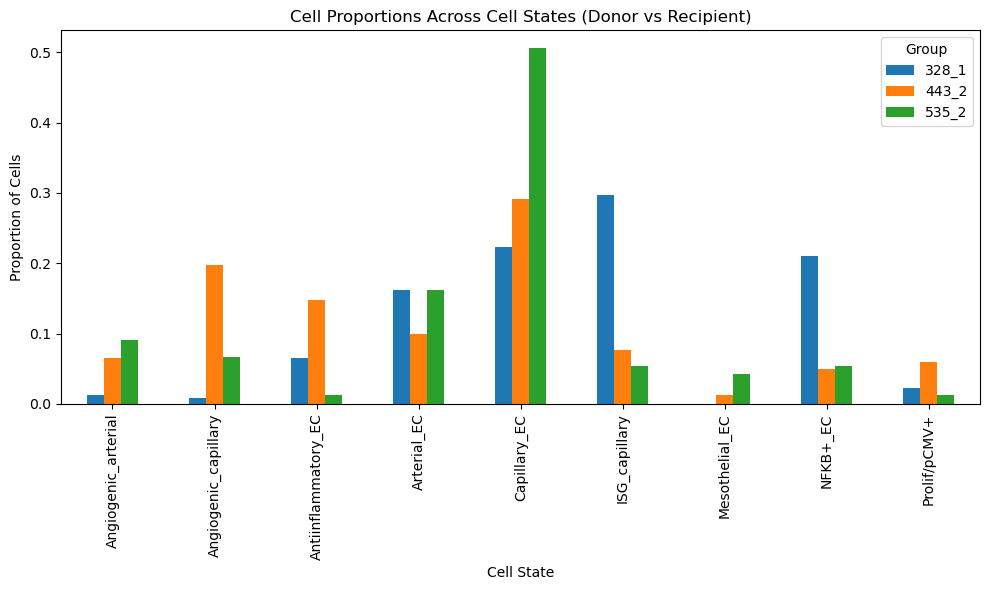

In [23]:
#Plot proportions of each cell states
group_col = 'sample'       
cell_state_col = 'cell_state'  

cell_counts = adata_afterinte.obs.groupby([group_col, cell_state_col]).size().reset_index(name='count')
total_counts = adata_afterinte.obs.groupby(group_col).size().reset_index(name='total')
cell_props = pd.merge(cell_counts, total_counts, on=group_col)
cell_props['proportion'] = cell_props['count'] / cell_props['total']
pivot_data = cell_props.pivot(index=cell_state_col, columns=group_col, values='proportion').fillna(0)
pivot_data.plot(kind='bar', figsize=(10, 6))

plt.title('Cell Proportions Across Cell States (Donor vs Recipient)')
plt.ylabel('Proportion of Cells')
plt.xlabel('Cell State')
plt.legend(title='Group')
plt.tight_layout()

plt.show()

/var/folders/_c/m4bk3hk95tv6mk2gt77lk_gc0000gn/T/ipykernel_54532/1290211090.py:6: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  cell_type_counts = adata_afterinte.obs.groupby(['sample', 'cell_state']).size().unstack(fill_value=0)


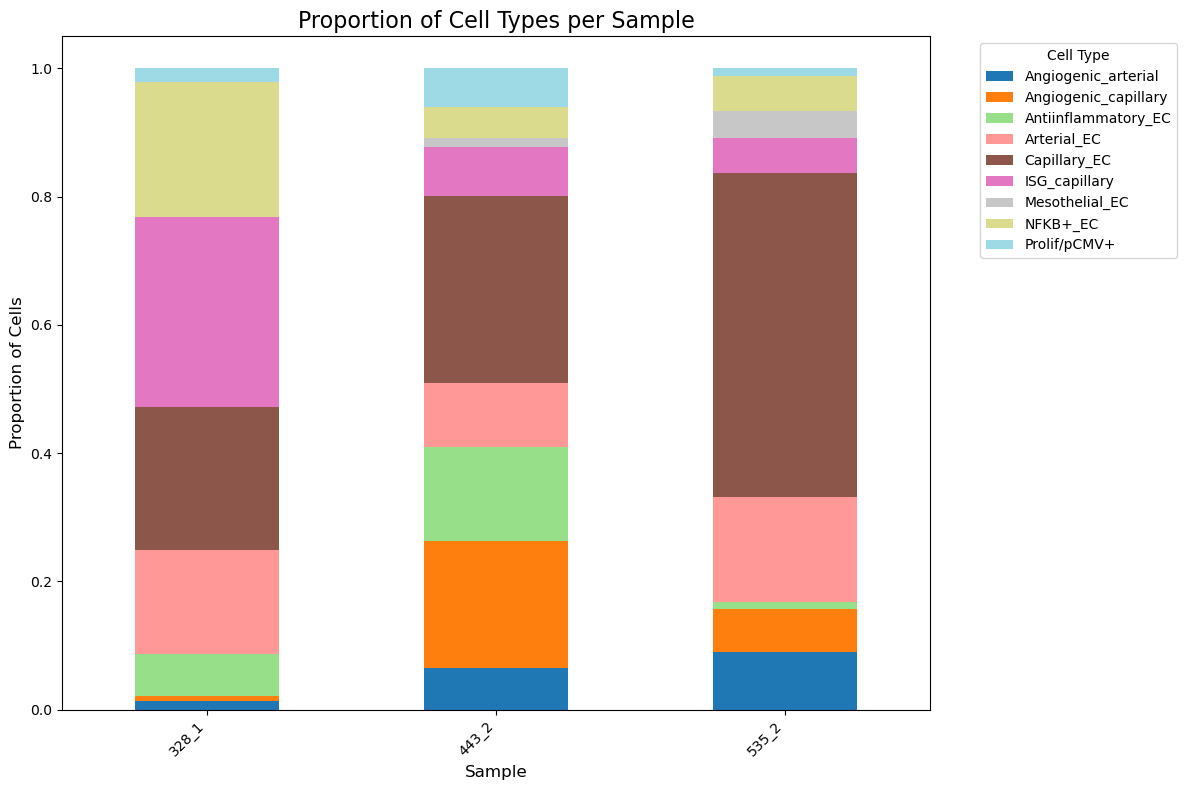

In [24]:
import pandas as pd
import matplotlib.pyplot as plt

# 1. Get the cell counts per sample and cell type
# Assuming adata_afterinte is your AnnData object
cell_type_counts = adata_afterinte.obs.groupby(['sample', 'cell_state']).size().unstack(fill_value=0)

# 2. Calculate the proportions for each sample
proportions = cell_type_counts.div(cell_type_counts.sum(axis=1), axis=0)

# 3. Create the stacked bar chart with a new colormap
# You can use a different colormap like 'viridis', 'plasma', 'tab20b', etc.
proportions.plot(kind='bar', stacked=True, figsize=(12, 8), cmap='tab20')

# 4. Add titles and labels
plt.title('Proportion of Cell Types per Sample', fontsize=16)
plt.xlabel('Sample', fontsize=12)
plt.ylabel('Proportion of Cells', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.legend(title='Cell Type', bbox_to_anchor=(1.05, 1), loc='upper left')

# 5. Show the plot
plt.tight_layout()
plt.show()